# Job Level Classification

Dự án NLP dự đoán **6 cấp bậc nghề nghiệp** từ nội dung tin tuyển dụng.

Quy trình: đọc dữ liệu → làm sạch → EDA → chia train/test → baseline → huấn luyện → đánh giá → dự đoán dữ liệu mới.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from src.config import DATA_PATH, RANDOM_STATE
from src.data import load_and_clean_data, split_features_target
from src.modeling import build_candidate_models
from src.predict import predict_job_level

## 1. Đọc và làm sạch dữ liệu

Các bước làm sạch được tái sử dụng từ `src/data.py`: loại dòng thiếu/trùng, sửa lỗi encoding, chuẩn hóa khoảng trắng và location.

In [2]:
data = load_and_clean_data(DATA_PATH)
print(f"Số dòng sau làm sạch: {len(data):,}")
print(f"Số cột: {data.shape[1]}")
display(data.head(3))

Số dòng sau làm sạch: 8,052
Số cột: 7


,title,location,description,function,industry,career_level,combined_text
0,Technical Professional Lead - Process,TX,"Responsible for the study, design, and specifi...",production_manufacturing,Machinery and Industrial Facilities Engineering,senior_specialist_or_project_manager,Technical Professional Lead - Process Technica...
1,Cnslt - Systems Eng- Midrange 1,WA,"Participates in design, development and implem...",information_technology_telecommunications,Financial Services,senior_specialist_or_project_manager,Cnslt - Systems Eng- Midrange 1 Cnslt - System...
2,SharePoint Developers and Solution Architects,TX,We are currently in need of Developers who can...,consulting,IT Consulting,senior_specialist_or_project_manager,SharePoint Developers and Solution Architects ...


## 2. Khám phá dữ liệu

Dataset mất cân bằng mạnh, vì vậy không thể chỉ dựa vào accuracy. Macro-F1 được dùng để đánh giá công bằng hơn giữa các lớp.

,count,percentage
career_level,,
senior_specialist_or_project_manager,4323,53.69
manager_team_leader,2667,33.12
bereichsleiter,958,11.90
director_business_unit_leader,70,0.87
specialist,30,0.37
managing_director_small_medium_company,4,0.05


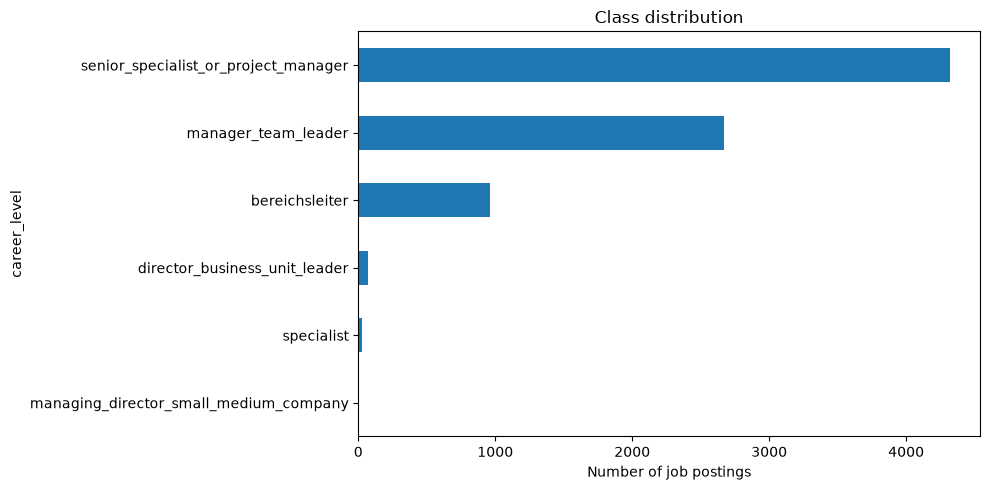

In [3]:
class_counts = data["career_level"].value_counts()
display(pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(data) * 100).round(2),
}))

class_counts.sort_values().plot(kind="barh", figsize=(10, 5), title="Class distribution")
plt.xlabel("Number of job postings")
plt.tight_layout()
plt.show()

## 3. Chia tập train/test

Dùng `stratify=y` để giữ tỷ lệ các lớp giữa hai tập.

In [4]:
X, y = split_features_target(data)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"Train: {len(X_train):,} mẫu")
print(f"Test:  {len(X_test):,} mẫu")

Train: 6,441 mẫu
Test:  1,611 mẫu


## 4. Baseline và các mô hình

- Baseline luôn dự đoán lớp phổ biến nhất.
- Logistic Regression và Linear SVM sử dụng cùng pipeline TF-IDF + One-Hot Encoding.
- `class_weight='balanced'` hỗ trợ xử lý mất cân bằng.

In [5]:
from src.train import calculate_metrics

results = {}
models = {}
predictions = {}

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
results["Baseline"] = calculate_metrics(y_test, baseline.predict(X_test))

for name, model in build_candidate_models().items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    models[name] = model
    predictions[name] = prediction
    results[name] = calculate_metrics(y_test, prediction)

comparison = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
display(comparison.round(4))

,accuracy,macro_f1,weighted_f1,balanced_accuracy
Linear SVM,0.7871,0.5406,0.7793,0.4917
Logistic Regression,0.7716,0.5286,0.7702,0.5357
Baseline,0.5369,0.1165,0.3752,0.1667


## 5. Đánh giá mô hình tốt nhất

Best model: Linear SVM
                                        precision    recall  f1-score   support

                        bereichsleiter       0.55      0.41      0.47       192
         director_business_unit_leader       0.80      0.57      0.67        14
                   manager_team_leader       0.72      0.72      0.72       533
managing_director_small_medium_company       0.00      0.00      0.00         1
  senior_specialist_or_project_manager       0.86      0.92      0.89       865
                            specialist       1.00      0.33      0.50         6

                              accuracy                           0.79      1611
                             macro avg       0.66      0.49      0.54      1611
                          weighted avg       0.78      0.79      0.78      1611



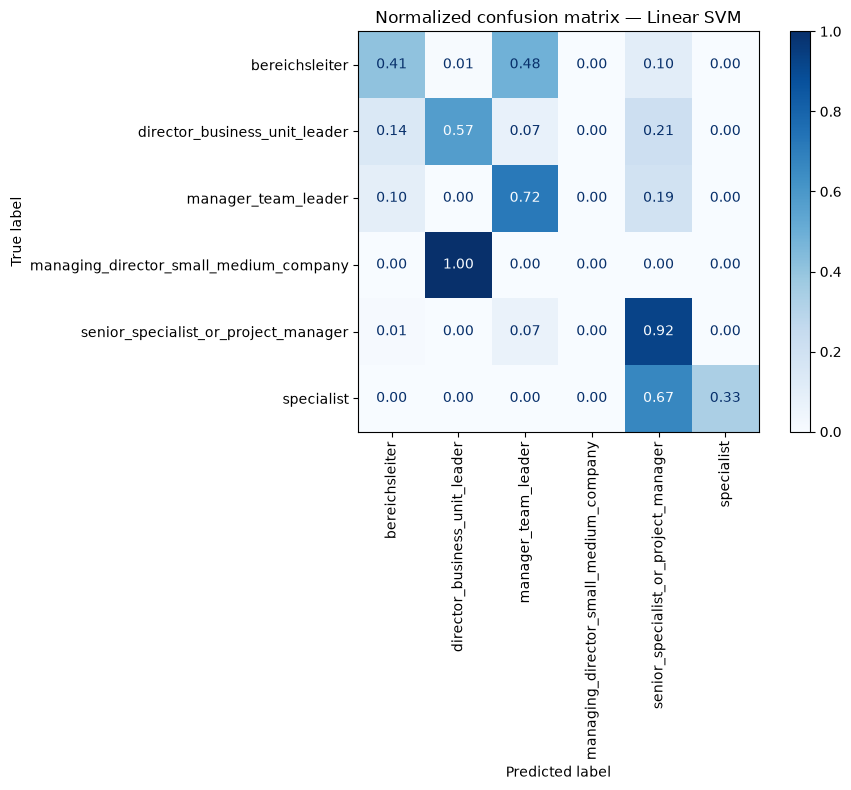

In [6]:
best_name = max(models, key=lambda name: results[name]["macro_f1"])
best_model = models[best_name]
best_prediction = predictions[best_name]

print("Best model:", best_name)
print(classification_report(y_test, best_prediction, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    normalize="true",
    xticks_rotation="vertical",
    cmap="Blues",
    values_format=".2f",
    ax=ax,
)
plt.title(f"Normalized confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 6. Dự đoán dữ liệu mới

Đây là phần input/output có thể dùng để demo khi phỏng vấn.

In [7]:
result = predict_job_level(
    best_model,
    title="Senior Software Engineering Manager",
    location="Austin, TX",
    description="Lead engineers, mentor staff and manage project delivery.",
    function="information_technology_telecommunications",
    industry="Information Technology",
)

print("Predicted career level:", result["display_name"])
display(pd.DataFrame(result["ranking"][:3]))

Predicted career level: Manager / Team Leader


,label,display_name,score
0,manager_team_leader,Manager / Team Leader,0.591681
1,specialist,Specialist,0.097072
2,bereichsleiter,Department Head,0.093487


## Kết luận

- Đã xử lý hơn 8.000 tin tuyển dụng.
- Đã xây dựng bài toán phân loại 6 cấp bậc.
- Đã sử dụng TF-IDF, One-Hot Encoding và class weighting.
- Đã so sánh baseline, Logistic Regression và Linear SVM.
- Linear SVM đạt accuracy khoảng **78,71%** và macro-F1 khoảng **54,06%**.
- Model có thể nhận tin tuyển dụng mới và trả về cấp bậc dự đoán.